In [13]:
# 1. IMPORT LIBRARIES 
import os, re, json, warnings, joblib
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings('ignore')


In [14]:
# 2. LOAD DATASET 
resource_path = 'python_chatbot/model_resource/'
excel_path = os.path.join(resource_path, 'Label Pertanyaan.xlsx')
if not os.path.isfile(excel_path):
    raise FileNotFoundError(f'Dataset not found at {excel_path}')
df = pd.read_excel(excel_path).drop_duplicates().dropna()
print(f'Loaded {len(df)} rows.')


Loaded 800 rows.


In [15]:
# 3. PRE‑PROCESSING (slang & cleaning) 
slang_path = os.path.join(resource_path, 'slang.json')
try:
    with open(slang_path, 'r', encoding='utf-8') as f:
        slang_dict = json.load(f)
except FileNotFoundError:
    slang_dict = {}
    print('[WARN] slang.json not found – proceeding without slang replacement.')
multi_slang = sorted([(k,v) for k,v in slang_dict.items() if ' ' in k], key=lambda x: len(x[0]), reverse=True)
def clean_text(t: str) -> str:
    if not t:
        return ''
    t = re.sub(r'[^a-z0-9\s]', ' ', str(t).lower()).strip()
    for frm, to in multi_slang:
        t = re.sub(r'\b' + re.escape(frm) + r'\b', to, t)
    return ' '.join(slang_dict.get(tok, tok) for tok in t.split())
df['teks_bersih'] = df['Pertanyaan'].apply(clean_text)
print('Sample cleaned texts:')
print(df[['Pertanyaan','teks_bersih']].head().to_string(index=False))


Sample cleaned texts:
                                          Pertanyaan                                                  teks_bersih
Assalamualaikum admin, selamat pagi bisa bantu saya?          assalamualaikum admin selamat pagi bisa tolong saya
      Halo selamat siang, saya mau bertanya sebentar                   halo selamat siang saya mau tanya sebentar
  Permisi admin, apakah layanan informasi ini aktif?                permisi admin apa layanan informasi ini aktif
    Selamat pagi, saya pengunjung baru di RSJ Tampan selamat pagi saya pengunjung baru di rumah sakit jiwa tampan
 Mohon maaf mengganggu waktunya, saya ingin bertanya              mohon maaf mengganggu waktunya saya ingin tanya


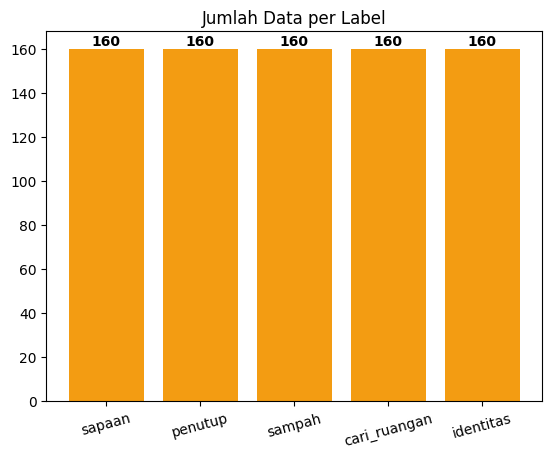

In [16]:
# VISUALISASI JUMLAH DATA PER LABEL
counts = df['Label'].value_counts()
plt.bar(counts.index, counts.values, color='#F39C12')
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.title('Jumlah Data per Label')
plt.xticks(rotation=15) # Miringkan teks label agar tidak bertabrakan
plt.show()

In [17]:
# 4. EMBEDDING (S-BERT) 
import os
os.environ.update({"HF_HUB_OFFLINE":"1", "TRANSFORMERS_OFFLINE":"1"})
embedder = SentenceTransformer("python_chatbot/model_resource/sbert_miniLM", device="cpu")
vectors = embedder.encode(df['teks_bersih'].tolist(), show_progress_bar=False)
print(f'Embeddings shape: {vectors.shape}')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9466.88it/s]


Embeddings shape: (800, 384)


In [28]:
# 5. TRAIN-TEST SPLIT & L2 NORMALIZATION 
X_train, X_test, y_train, y_test = train_test_split(vectors, df['Label'], test_size=0.2, stratify=df['Label'], random_state=42)
X_train = normalize(X_train)
X_test = normalize(X_test)
print(f'Train size {len(X_train)}, Test size {len(X_test)}')


print('\n Rincian Label pada Data Test:')
print(y_test.value_counts().to_string())


Train size 640, Test size 160

 Rincian Label pada Data Test:
Label
sampah          32
identitas       32
sapaan          32
penutup         32
cari_ruangan    32


In [19]:
#  6. TRAIN LINEAR SVM (LinearSVC) 
svm = LinearSVC()
svm.fit(X_train, y_train)
print('LinearSVC trained.')


LinearSVC trained.


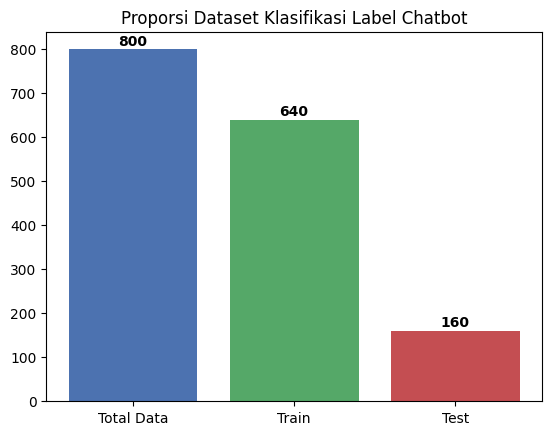

In [24]:
# 6.5 VISUALISASI PROPORSI DATASET
nilai = [len(df), len(X_train), len(X_test)]
plt.bar(['Total Data', 'Train', 'Test'], nilai, color=['#4C72B0', '#55A868', '#C44E52'])

for i, v in enumerate(nilai):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.title('Proporsi Dataset Klasifikasi Label Chatbot')
plt.show()


In [21]:
# 7. EVALUATION 
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Linear SVM accuracy: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))


Linear SVM accuracy: 94.38%
              precision    recall  f1-score   support

cari_ruangan       0.97      0.94      0.95        32
   identitas       0.94      0.97      0.95        32
     penutup       0.97      0.97      0.97        32
      sampah       0.91      0.94      0.92        32
      sapaan       0.94      0.91      0.92        32

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160



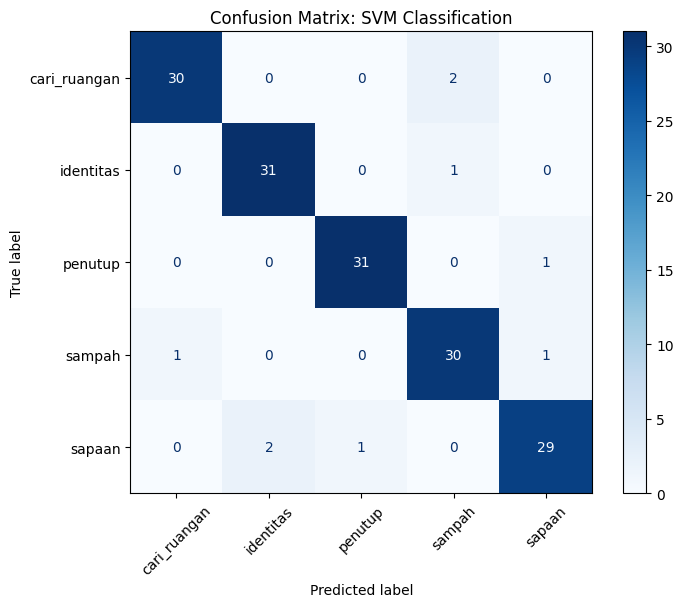

In [22]:
# 8. Confussion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix: SVM Classification')
plt.show()

In [23]:
# 9. SAVE MODEL (compatible with existing engine) 
resource_path = os.path.join(resource_path, 'modelLabel.pkl')
model_dict = {
    'classifier': svm,
    'labels_intent': list(svm.classes_),
    'embedder_name': 'paraphrase-multilingual-MiniLM-L12-v2',
    'slang_dict': slang_dict,
    'metode': 'linear_svm_sbert'
}
joblib.dump(model_dict, resource_path)
print(f'Model saved to {resource_path}')


Model saved to python_chatbot/model_resource/modelLabel.pkl
